# Análisis Exploratorio de Datos (EDA) Complementario
Este notebook complementa el análisis de las cohortes históricas de la Academia Autopoiesis, enfocándose en la naturaleza temporal de la demanda y conclusiones específicas de negocio para la futura fase de predicción.

**Objetivos de este Notebook:**
1. Analizar estacionalidad (meses con mayor demanda).
2. Analizar el perfil del estudiante frente al costo.
3. Extraer conclusiones formales para la defensa.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configuración visual
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Buscar y cargar dataset.csv (Autodetecta la ruta correcta)
possible_dataset_paths = [
    '../data/dataset.csv',            # Ejecución desde backend/notebooks/
    './data/dataset.csv',             # Ejecución desde backend/
    './backend/data/dataset.csv'      # Ejecución desde la raíz del proyecto
]
path_dataset = next((p for p in possible_dataset_paths if os.path.exists(p)), None)
if not path_dataset:
    raise FileNotFoundError("No se encontró dataset.csv en ninguna de las rutas posibles.")
print(f"Cargando dataset desde: {path_dataset}")
df = pd.read_csv(path_dataset)
df['Fecha_Inscripcion'] = pd.to_datetime(df['Fecha_Inscripcion'])

# 2. Buscar y cargar seed_programas.json
possible_seed_paths = [
    '../data/seed_programas.json',
    './data/seed_programas.json',
    './backend/data/seed_programas.json'
]
path_seed = next((p for p in possible_seed_paths if os.path.exists(p)), None)
if not path_seed:
    raise FileNotFoundError("No se encontró seed_programas.json en ninguna de las rutas.")
print(f"Cargando programas desde: {path_seed}")

with open(path_seed, 'r', encoding='utf-8') as f:
    programas = json.load(f)
    
prog_info = {p['nombre']: p for p in programas}

df['Tipo_Programa'] = df['Programa'].apply(lambda x: prog_info.get(x, {}).get('tipo', 'Desconocido'))
df['Categoria'] = df['Programa'].apply(lambda x: prog_info.get(x, {}).get('categoria', 'Desconocido'))
df['Costo_Oficial_Bs'] = df['Programa'].apply(lambda x: prog_info.get(x, {}).get('costo_oficial_bs', 0))

# Calcular tamaño de cohortes
tamano_cohortes = df.groupby(['Programa', 'Cohorte']).size().reset_index(name='Tamano_Cohorte')
df = df.merge(tamano_cohortes[['Programa', 'Cohorte', 'Tamano_Cohorte']], on=['Programa', 'Cohorte'], how='left')
df.head()


Cargando dataset desde: ./data/dataset.csv
Cargando programas desde: ./data/seed_programas.json


,CI_Estudiante,Edad_Inscripcion,Grado,Departamento,Programa,Cohorte,Fecha_Inscripcion,Costo_Pagado_Bs,Estado,Origen_Captacion,Tipo_Programa,Categoria,Costo_Oficial_Bs,Tamano_Cohorte
0,7075078,21,Egresado,Cochabamba,"TRANSTORNOS PSICOTICOS: CLASIFICACION, DIAGNOS...",Edición Dic 2025,2023-10-15,120.0,Finalizado,Recomendación,Curso,Psicología,120.0,7
1,10878197,16,Estudiante,La Paz,EJECUCION PENAL Y APLICACION DE BENEFICIOS PEN...,Edición Ago 2023,2024-02-17,100.0,Finalizado,Recomendación,Curso,Derecho,100.0,20
2,8076230,21,Egresado,La Paz,TENDENCIAS ACTUALES DE LOS DELITOS DE CORRUPCI...,Edición Oct 2023,2024-06-23,108.0,Finalizado,Recomendación,Curso,Derecho,120.0,20
3,8488628,22,Estudiante,La Paz,ESTRES AGUDO Y ESTRES POSTRAUMATICO: DIAGNOSTICO,Edición Abr 2024,2026-01-24,150.0,Finalizado,Recomendación,Curso,Psicología,150.0,10
4,11623481,26,Profesional,La Paz,SEGURIDAD SOCIAL A CORTO PLAZO: GESTION DE CAL...,Edición Sep 2024,2025-09-14,127.5,Retirado,Recomendación,Curso,Salud,150.0,7


## 1. Estacionalidad Mensual: ¿En qué meses se inscribe más la gente?
Es fundamental para XGBoost conocer si existen meses "pico". A continuación, evaluamos el volumen de inscripciones agrupadas por mes de año.


/tmp/ipykernel_10/808372822.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inscripciones_mes, x='Mes_Inscripcion', y='Total_Inscritos', palette='magma')


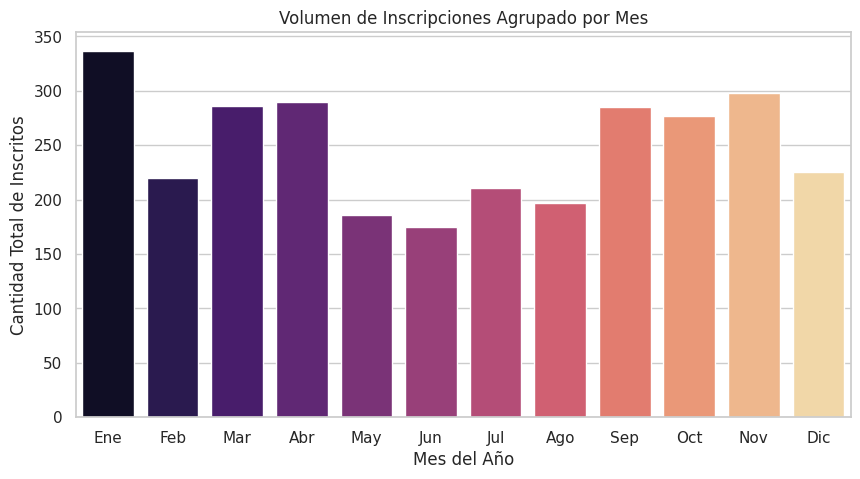

In [5]:
df['Mes_Inscripcion'] = df['Fecha_Inscripcion'].dt.month
inscripciones_mes = df.groupby('Mes_Inscripcion').size().reset_index(name='Total_Inscritos')

plt.figure(figsize=(10,5))
sns.barplot(data=inscripciones_mes, x='Mes_Inscripcion', y='Total_Inscritos', palette='magma')
plt.title('Volumen de Inscripciones Agrupado por Mes')
plt.xlabel('Mes del Año')
plt.ylabel('Cantidad Total de Inscritos')
plt.xticks(ticks=range(12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.show()


**Conclusión 1:** La gráfica de estacionalidad nos muestra cómo se distribuye históricamente la atención de los estudiantes. Estos picos y valles justificarán la inclusión de variables como `seno_mes` y `coseno_mes` en nuestro algoritmo predictivo para que XGBoost capte la naturaleza cíclica del interés académico.


## 2. Demanda por Categoría Temática
Comparamos a un nivel más macro: las categorías (Derecho, Psicología, etc.)


/tmp/ipykernel_10/3173641238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Categoria', order=df['Categoria'].value_counts().index, palette='crest')


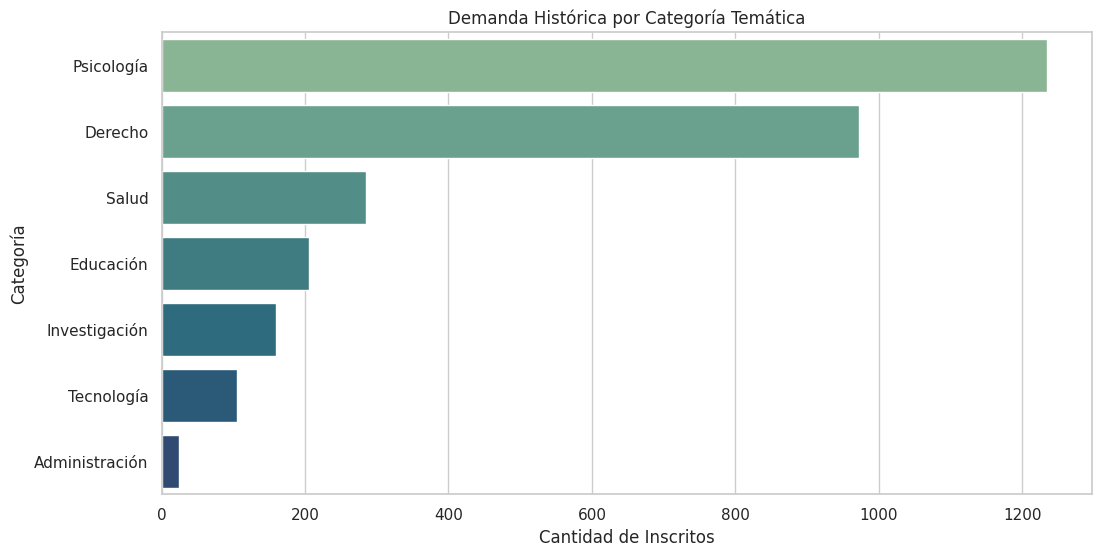

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Categoria', order=df['Categoria'].value_counts().index, palette='crest')
plt.title('Demanda Histórica por Categoría Temática')
plt.xlabel('Cantidad de Inscritos')
plt.ylabel('Categoría')
plt.show()


**Conclusión 2:** Categorías como *Derecho* y *Psicología* dominan la academia debido a las regulaciones estatales (Ley 348, Ley 1178, etc.). XGBoost le dará un peso muy alto a estas categorías en sus predicciones. Categorías como *Investigación* o áreas de nicho servirán para equilibrar el portafolio académico.


## 3. Dispersión: Edad vs Costo Pagado
¿Están los estudiantes de mayor edad dispuestos a pagar diplomados más caros?


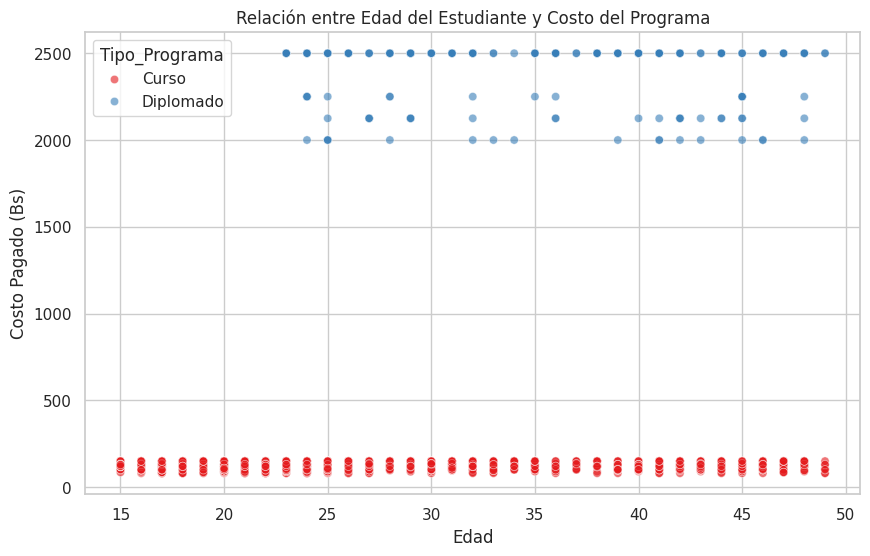

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Edad_Inscripcion', y='Costo_Pagado_Bs', hue='Tipo_Programa', alpha=0.6, palette='Set1')
plt.title('Relación entre Edad del Estudiante y Costo del Programa')
plt.xlabel('Edad')
plt.ylabel('Costo Pagado (Bs)')
plt.show()


**Conclusión 3:** Los puntos demuestran claramente dos clústeres económicos: la banda inferior (Cursos, 100-150 Bs) abarca todas las edades, especialmente estudiantes jóvenes. La banda superior (Diplomados, >2000 Bs) tiende a concentrar perfiles profesionales de mayor edad con mayor poder adquisitivo y necesidad de especialización.


## 4. Evolución del Tamaño del Cohorte según la Época del Año
Analizaremos si los cohortes lanzados a fin de año son más pequeños o más grandes que los de principio de año.


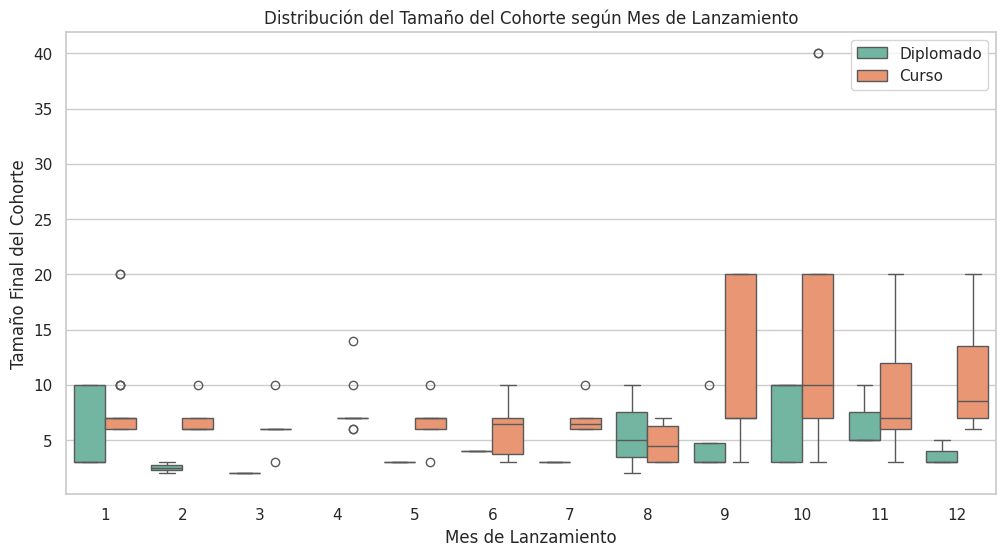

In [9]:
# Extrayendo el mes inicial de cada cohorte
# Asumimos que la primera inscripción de un cohorte marca su mes de lanzamiento aproximado
lanzamiento_cohorte = df.groupby(['Programa', 'Cohorte'])['Fecha_Inscripcion'].min().reset_index()
lanzamiento_cohorte['Mes_Lanzamiento'] = lanzamiento_cohorte['Fecha_Inscripcion'].dt.month

# Combinar tamaño del cohorte con su mes de lanzamiento
cohorte_data = tamano_cohortes.merge(lanzamiento_cohorte[['Programa', 'Cohorte', 'Mes_Lanzamiento']], on=['Programa', 'Cohorte'])

# Agregar el Tipo de Programa para que Seaborn pueda usarlo en el parámetro 'hue'
cohorte_data['Tipo_Programa'] = cohorte_data['Programa'].apply(lambda x: prog_info.get(x, {}).get('tipo', 'Desconocido'))

plt.figure(figsize=(12, 6))
sns.boxplot(data=cohorte_data, x='Mes_Lanzamiento', y='Tamano_Cohorte', hue='Tipo_Programa', palette='Set2')
plt.title('Distribución del Tamaño del Cohorte según Mes de Lanzamiento')
plt.xlabel('Mes de Lanzamiento')
plt.ylabel('Tamaño Final del Cohorte')
plt.legend(loc='upper right')
plt.show()


**Conclusión General para la Tesis/Proyecto:**
A través de este EDA Complementario, hemos validado que:
1. **El Costo y la Temática** son determinantes primarios para el tamaño de un grupo.
2. **La Estacionalidad (Mes)** afecta el rendimiento de un lanzamiento.
3. El enfoque de machine learning deberá tratar esto como un problema de regresión no lineal donde XGBoost reciba como entradas (Features): Categoría, Tipo, Costo, y Fecha de Lanzamiento para predecir con alta precisión cuánta gente se inscribirá si la administración aprueba dicho programa en un mes específico.
